In [ ]:
try:
    import firedrake
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/firedrake-install-release-real.sh" -O "/tmp/firedrake-install.sh" && bash "/tmp/firedrake-install.sh"
    import firedrake

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [3]:
from firedrake import *
import matplotlib.pyplot as plt
import numpy as np

from firedrake.petsc import PETSc

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


In [1]:
# Get current path: all relative paths that you may use for input/output start from here.
#
# - Colab:  The default path is /content, and your GDrive folder is accessible (if mounted) at /content/drive/MyDrive
#
# - local:  If running on your local machine, current_path is the position WHERE YOU LAUNCHED THE NOTEBOOK KERNEL BY 'jupyter notebook'
#           and NOT the directory in which this ipynb file is saved.
#           If you want to modify your current path, go to the terminal, stop the kernel (ctrl-C + press y), then move to the desired path by
#           cd my/desired/path/starting/from/here
#           and then launch 'jupyter notebook'.
import os
current_path = os.getcwd()
print(current_path)

my_io_path = current_path + "/cfd-labs/Lab10-NS-ChorinTemam/" 
# my_io_path = current_path+"/"
print(my_io_path)

/home/aless
/home/aless/cfd-labs/Lab10-NS-ChorinTemam/


---
---
# Exercise 1 - Chorin-Temam projection method

\begin{equation*}
\begin{cases}
\frac{\partial  \boldsymbol{u}}{\partial t}+ ( \boldsymbol{u}\cdot \nabla)  \boldsymbol{u}- \frac{1}{\text{Re}}\nabla\cdot(\nabla\boldsymbol{u}+\nabla\boldsymbol{u}^T) + \nabla  p  = \boldsymbol{0} & {\rm in} \ \Omega, t\in(0,T),\\
\nabla \cdot \boldsymbol{u} = 0 & {\rm in} \ \Omega, t\in(0,T), \\
\boldsymbol{u} = \boldsymbol{u}_\text{in} & {\rm on} \ \Gamma_{\rm{in}}, t\in(0,T),\\
\sigma(\boldsymbol{u},p)\boldsymbol{n} = h_\text{out}\boldsymbol{n} & {\rm on} \ \Gamma_{\rm{out}}, t\in(0,T), \\
\boldsymbol{u} = \boldsymbol{0} & {\rm on} \ \partial\Omega\setminus(\Gamma_\text{in}\cup\Gamma_\text{out}), t\in(0,T),\\
\boldsymbol{u}|_{t=0} = \boldsymbol{u}_\text{Stokes} & {\rm in} \ \Omega, t=0
\end{cases}
\end{equation*}

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (5,) is empty. This is likely an error. Did you choose the right label?


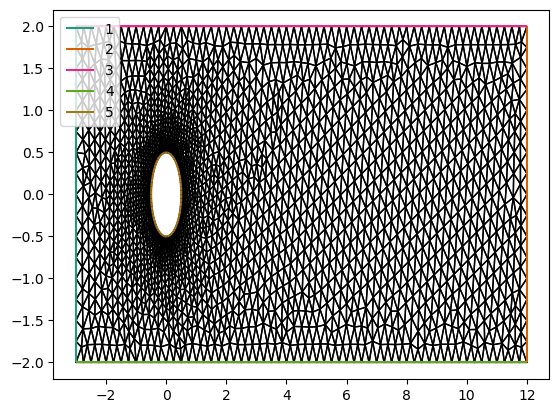

In [4]:
# Import mesh: set the path correctly!
mesh = Mesh(my_io_path+'mesh/cylinder-ns.msh')
fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend(loc='upper left')

### Variational forms for incremental Chorin-Temam steps

In [17]:
# Forms for step 1
def predictor_forms(u, v, Re, dt, u_old, p_old, neumann_data, neumann_tag):
    a = 1.0/dt*inner(u, v) * dx + inner(dot(grad(u), u_old), v) * dx + 2.0/Re*inner(sym(grad(u)), sym(grad(v))) * dx
    L = 1.0/dt*inner(u_old, v) * dx - inner(grad(p_old), v) * dx \
        + inner(neumann_data, v) * ds(neumann_tag)
    return a, L

# Forms for step 2 (incremental)
def pressure_forms(dp, q, dt, u_tilde):
    a = inner(grad(dp), grad(q)) * dx
    L = -1.0/dt*div(u_tilde) * q * dx
    return a, L

# Forms for step 3: uh and grad(ph) belong to different FE spaces
def projection_forms(u, v, u_tilde, dp, dt):
    a = inner(u, v) * dx
    L = inner(u_tilde, v) * dx - dt * inner(grad(dp), v) * dx
    return a, L

### FE spaces, data, BCs

In [18]:
# Function spaces (separated: no MixedFunctionSpace needed)
# The bubble enrichment of the velocity space has to be done at the finite element level: see Lab02.
V1_el = FiniteElement('CG', mesh.ufl_cell(), 1)
B_el = FiniteElement('Bubble', mesh.ufl_cell(), mesh.topological_dimension + 1)
V_el = VectorElement(NodalEnrichedElement(V1_el, B_el))
V = FunctionSpace(mesh, V_el)
Q = FunctionSpace(mesh, 'P', 1)

# Data
Re = 200
f = Constant((0., 0.))
t = 0
T = 50
dt = 0.5

x = SpatialCoordinate(mesh)

# Boundary conditions - velocity
u_in = (3.0/8.0*(2-x[1])*(2+x[1]), 0.)
h_out = Constant(0.5)
bcU_in = DirichletBC(V, u_in, 1)
bcU_wall = DirichletBC(V, Constant((0.,0.)), (3,4,5))
bcsU = (bcU_in, bcU_wall)

# Boundary conditions - pressure
bcsP = ( DirichletBC(Q, Constant(0.), 2) ) # parentheses to make it a tuple (with a single element)

### Initial condition

In [19]:
W = MixedFunctionSpace([V, Q])  # only for Stokes problem
uu, pp = TrialFunctions(W)
vv, qq = TestFunctions(W)

# Stokes problem
a_init = 2.0/Re * inner(sym(grad(uu)), sym(grad(vv))) * dx - pp * div(vv) * dx + qq * div(uu) * dx
normal = FacetNormal(mesh)
L_init = inner(f, vv) * dx + inner(h_out*normal, vv) * ds(2)
bc_in_init = DirichletBC(W.sub(0), u_in, 1)
bc_wall_init = DirichletBC(W.sub(0), Constant((0.,0.)), (3,4,5))


wh_init = Function(W)
solve(a_init == L_init, wh_init, bcs = (bc_in_init, bc_wall_init))
uh_init, ph_init = wh_init.subfunctions

# Functions on separated space, for C-T scheme
uh_old = Function(V)
ph_old = Function(Q)
uh_old.assign(uh_init)
ph_old.assign(ph_init)

Coefficient(WithGeometry(FunctionSpace(<firedrake.mesh.MeshTopology object at 0x73373a273b90>, FiniteElement('Lagrange', triangle, 1), name=None), Mesh(VectorElement(FiniteElement('Lagrange', triangle, 1), dim=2), 1)), 205)

### Post-processing

NameError: name 'File' is not defined

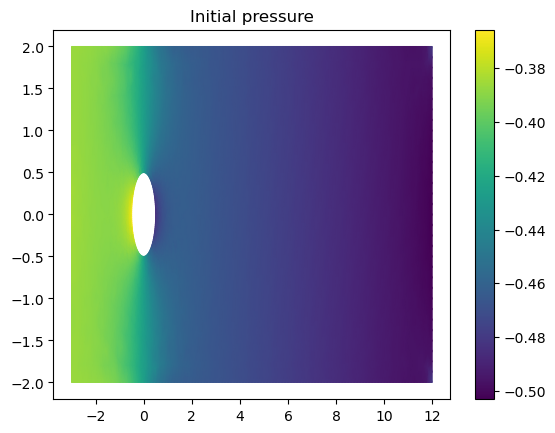

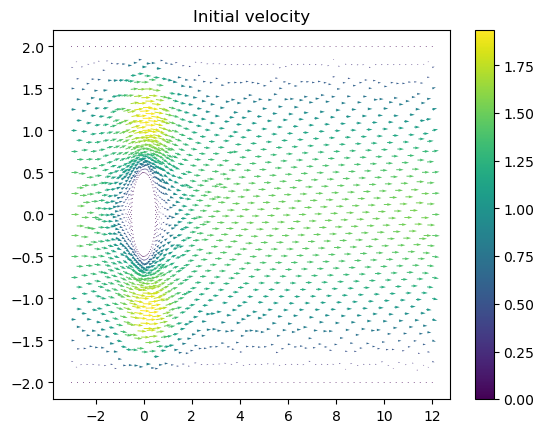

In [20]:
fig, ax = plt.subplots()
col = tripcolor(ph_old, axes=ax)
plt.colorbar(col)
plt.title('Initial pressure')

fig, ax = plt.subplots()
col = quiver(uh_old, axes=ax)
plt.colorbar(col)
plt.title('Initial velocity')

# vtk output for Paraview
basename = 'lab10_'
outfileU = File(my_io_path+"output/"+basename+"velocity.pvd")
outfileP = File(my_io_path+"output/"+basename+"pressure.pvd")
uh_old.rename("Velocity")   # this names will be used in Paraview
ph_old.rename("Pressure")
outfileU.write(uh_old)
outfileP.write(ph_old)

### Definition of steps

In [21]:
# For variational problems
u = TrialFunction(V)
v = TestFunction(V)
dp = TrialFunction(Q)   # incremental
q = TestFunction(Q)

# Actual solution
uh = Function(V)
dph = Function(Q)       # incremental

# Step 1
a1, L1 = predictor_forms(u, v, Re, dt, uh_old, ph_old, h_out*normal, 2)
step1_pb = LinearVariationalProblem(a1, L1, uh, bcsU)
step1 = LinearVariationalSolver(step1_pb, solver_parameters={'ksp_type': 'preonly', 'pc_type':'lu'})
# Then, step1.solve() will compute "u_tilde" and store it in uh

# Step 2
a2, L2 = pressure_forms(dp, q, dt, uh)  # uh = "u_tilde" from solution of step1
step2_pb = LinearVariationalProblem(a2, L2, dph, bcsP)
step2 = LinearVariationalSolver(step2_pb, solver_parameters={'ksp_type': 'preonly', 'pc_type':'lu'})

# Step 3
a3, L3 = projection_forms(u, v, uh, dph, dt)  # uh = "u_tilde" from step1; dph from step 2
step3_pb = LinearVariationalProblem(a3, L3, uh) # no BCs
step3 = LinearVariationalSolver(step3_pb, solver_parameters={'ksp_type': 'preonly', 'pc_type':'lu'})

### Time-dependent solution

In [ ]:
t_vec = np.arange(0, T+0.1*dt, dt)  # T+0.1*dt to include also T: range/arange exclude the upper bound of the range
drag_vec = [0.0] * len(t_vec)
lift_vec = [0.0] * len(t_vec)
drag_vec[0] = assemble( inner( ph_old*normal - 2.0/Re*dot(sym(grad(uh_old)), normal), Constant((1.,0.)) ) * ds(5) )
lift_vec[0] = assemble( inner( ph_old*normal - 2.0/Re*dot(sym(grad(uh_old)), normal), Constant((0.,1.)) ) * ds(5) )
for ii in range(1, len(t_vec)):     # start from 1 to skip t=0
    t = t_vec[ii]
    print('t =', t)
    print('||u||_{H^1} =', norm(uh_old,'H1'), '  ||p||_{L^2} =', norm(ph_old,'L2')) # to check the solution is not blowing up
    step1.solve()
    step2.solve()
    step3.solve()

    uh_old.assign(uh)
    ph_old.dat += dph.dat   # step 4
    # or alternatively:
    # tmp_p = ph_old + dph
    # ph_old.assign(tmp_p)  # step 4

    # Post-processing
    outfileU.write(uh_old, time=t)
    outfileP.write(ph_old, time=t)

    drag_vec[ii] = assemble( inner( ph_old*normal - 2.0/Re*dot(sym(grad(uh_old)), normal), Constant((1.,0.)) ) * ds(5) )
    lift_vec[ii] = assemble( inner( ph_old*normal - 2.0/Re*dot(sym(grad(uh_old)), normal), Constant((0.,1.)) ) * ds(5) )

    print('drag =', drag_vec[ii], '   lift =', lift_vec[ii])

t = 0.5
||u||_{H^1} = 12.852304141620802   ||p||_{L^2} = 3.559882625362689
drag = 0.9610593091785872    lift = -0.0007694727291524706
t = 1.0
||u||_{H^1} = 15.116483383472842   ||p||_{L^2} = 3.5050628382800704
drag = 1.3763948165793594    lift = -0.0004579929338415908
t = 1.5
||u||_{H^1} = 15.389425249069541   ||p||_{L^2} = 3.4355353257682872
drag = 1.516683010644003    lift = -0.0009069969527071108
t = 2.0
||u||_{H^1} = 16.423161683518025   ||p||_{L^2} = 3.538958917785607
drag = 1.5703171430777436    lift = -0.0026785168957691383
t = 2.5
||u||_{H^1} = 17.110207914093742   ||p||_{L^2} = 3.6418270261819905
drag = 1.5974302626568775    lift = -0.004639824544376632
t = 3.0
||u||_{H^1} = 17.71637161338297   ||p||_{L^2} = 3.748864631740793
drag = 1.6001230028231255    lift = -0.006130279500802684
t = 3.5
||u||_{H^1} = 18.153184124820847   ||p||_{L^2} = 3.8507078560529333
drag = 1.574774874762802    lift = -0.007417050165924589
t = 4.0
||u||_{H^1} = 18.492946523527973   ||p||_{L^2} = 3.95695

KeyboardInterrupt: 

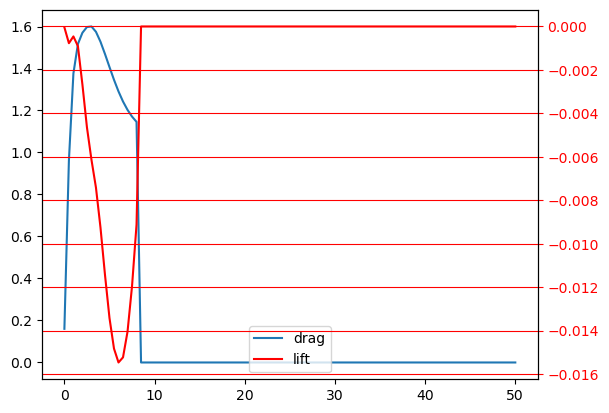

In [23]:
fig, ax1 = plt.subplots()
line1 = ax1.plot(t_vec, drag_vec, label='drag')

ax2 = ax1.twinx()   # same x axis, different y axis
line2 = ax2.plot(t_vec, lift_vec, label='lift', color='red')
ax2.grid(color='red')
ax2.tick_params(colors='red', axis='y')

lines = line1+line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower center')

# ax1.set_ylim(0, 0.7)
# ax2.set_ylim(-0.0003,0.0003)